# 1: Data Splitting and Verification Code

In [ ]:
# 1: Data Splitting and Verification Code
import os
import pandas as pd
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Define New Paths
DRIVE_ROOT = "/content/drive/MyDrive/DR_Project"
OUTPUT_ROOT = os.path.join(DRIVE_ROOT, "DR_Aptos_Only_224")
IMAGE_DIR = os.path.join(OUTPUT_ROOT, "images")
MASTER_CSV = os.path.join(OUTPUT_ROOT, "aptos_dataset_80_10_10.csv")
WEIGHTS_PATH = os.path.join(DRIVE_ROOT, "RetiZero.pth")

# --- NEW EXTRACT LOGIC ---
ZIP_PATH = os.path.join(DRIVE_ROOT, "DR_Aptos_Only_224.zip") # Make sure this name matches your zip exactly!

# Check if the CSV is missing. If so, unzip it.
if not os.path.exists(MASTER_CSV):
    print(f"CSV not found. Extracting {ZIP_PATH}...")
    !unzip -q "{ZIP_PATH}" -d "{DRIVE_ROOT}"
    print("Extraction complete!")
else:
    print("Files already extracted!")
# -------------------------

print(f"Loading master dataset from: {MASTER_CSV}")
df = pd.read_csv(MASTER_CSV)

# Generate Split CSVs from the Master CSV
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df = df[df['split'] == 'val'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

train_df.to_csv('train.csv', index=False)
val_df.to_csv('valid.csv', index=False)
test_df.to_csv('test.csv', index=False)

# Generate Dataset Statistics
print(" SPLIT SIZE & DISTRIBUTION VERIFICATION")
total_len = len(df)
print(f"Total images: {total_len}")
print(f"Train: {len(train_df)} ({len(train_df)/total_len:.1%})")
print(f"Val:   {len(val_df)} ({len(val_df)/total_len:.1%})")
print(f"Test:  {len(test_df)} ({len(test_df)/total_len:.1%})")

print("\n STRATIFICATION VERIFICATION (Class %)")
for name, data in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    dist = data['label'].value_counts(normalize=True).sort_index() * 100
    print(f"\n{name} Label Distribution (%):")
    for label, pct in dist.items():
        count = len(data[data['label'] == label])
        print(f"  Class {label}: {pct:.1f}% (n={count})")

print("\nSplits saved successfully as train.csv, valid.csv, and test.csv.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV not found. Extracting /content/drive/MyDrive/DR_Project/DR_Aptos_Only_224.zip...
Extraction complete!
Loading master dataset from: /content/drive/MyDrive/DR_Project/DR_Aptos_Only_224/aptos_dataset_80_10_10.csv

 SPLIT SIZE & DISTRIBUTION VERIFICATION
Total images: 3662
Train: 2929 (80.0%)
Val:   366 (10.0%)
Test:  367 (10.0%)

 STRATIFICATION VERIFICATION (Class %)

Train Label Distribution (%):
  Class 0: 49.3% (n=1444)
  Class 1: 10.1% (n=296)
  Class 2: 27.3% (n=799)
  Class 3: 5.3% (n=154)
  Class 4: 8.1% (n=236)

Val Label Distribution (%):
  Class 0: 49.2% (n=180)
  Class 1: 10.1% (n=37)
  Class 2: 27.3% (n=100)
  Class 3: 5.5% (n=20)
  Class 4: 7.9% (n=29)

Test Label Distribution (%):
  Class 0: 49.3% (n=181)
  Class 1: 10.1% (n=37)
  Class 2: 27.2% (n=100)
  Class 3: 5.2% (n=19)
  Class 4: 8.2% (n=30)

Splits saved successfully as train.csv, vali

#1.5: Environment Setup & Drive Mounting

In [ ]:
# 1. Mount Google Drive to access RetiZero.pth weights
from google.colab import drive
drive.mount('/content/drive')

# 2. Clone the RetiZero repository
!git clone https://github.com/LooKing9218/RetiZero.git

# 3. Install specific dependencies from their requirements
# (Colab has most of these, but kornia might be missing)
!pip install kornia~=0.6.10 transformers

# 4. Add the cloned repo to Python's search path
import sys
if '/content/RetiZero' not in sys.path:
    sys.path.append('/content/RetiZero')

print("\nGitHub repo cloned, Drive mounted, and paths configured!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'RetiZero' already exists and is not an empty directory.
  Using cached kornia-0.6.12-py2.py3-none-any.whl.metadata (12 kB)
Using cached kornia-0.6.12-py2.py3-none-any.whl (653 kB)

GitHub repo cloned, Drive mounted, and paths configured!


#2: Architecture & Dataloader Setup

In [ ]:
import os
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

if '/content/RetiZero' not in sys.path:
    sys.path.append('/content/RetiZero')

from iden_modules import CLIPRModel

# 1. Dataset Class
class RetiZeroDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]['image_file']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        label = int(self.data.iloc[idx]['label'])

        if self.transform:
            image = self.transform(image)

        return image, label

# 2. Focal Loss Implementation
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

# 3. Model Architecture (Patched for State Dict Keys)
class RetiZeroFinetune(nn.Module):
    def __init__(self, weight_path, num_classes=5):
        super().__init__()
        print(f"Loading RetiZero weights manually to bypass buffer mismatch...")


        self.retizero = CLIPRModel(vision_type="lora", from_checkpoint=False, R=8)


        state_dict = torch.load(weight_path, map_location="cpu")


        if "text_model.model.embeddings.position_ids" in state_dict:
            del state_dict["text_model.model.embeddings.position_ids"]


        self.retizero.load_state_dict(state_dict, strict=False)
        self.img_encoder = self.retizero.vision_model.model

        # Unfreeze all layers in the vision encoder for full fine-tuning
        for param in self.img_encoder.parameters():
            param.requires_grad = True

        # Swap the head: 1024-dim feature vector -> 5 classes
        self.classifier = nn.Linear(1024, num_classes)

    def forward(self, x):
        features = self.img_encoder(x)
        logits = self.classifier(features)
        return logits

# Initialization & Verification
def setup_step_2(image_dir, weights_path):
    print(" STEP 2: INITIALIZATION CHECK")

    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Test Dataloader
    try:
        test_dataset = RetiZeroDataset(csv_file='train.csv', img_dir=image_dir, transform=val_transforms)
        sample_img, sample_label = test_dataset[0]
        print(f"Dataloader successful! Sample image shape: {sample_img.shape}, Label: {sample_label}")
    except Exception as e:
        print(f"Dataloader failed. Check your image_dir path. Error: {e}")
        return

    #Test Model Instantiation & Forward Pass
    try:

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {device}")

        # Load model and push to device
        model = RetiZeroFinetune(weight_path=weights_path, num_classes=5).to(device)
        is_unfrozen = next(model.img_encoder.parameters()).requires_grad
        print(f"Model initialized! Vision encoder unfrozen: {is_unfrozen}")

        # Create dummy input and push to device
        dummy_input = torch.randn(2, 3, 224, 224).to(device)
        output = model(dummy_input)
        print(f"Forward pass successful! Output shape: {output.shape} (Expected: [2, 5])")
    except Exception as e:
        print(f"Model initialization failed. Error: {e}")
        return

    print("\nAll Step 2 checks passed. Ready for the training loop.")

# Run the setup
setup_step_2(IMAGE_DIR, WEIGHTS_PATH)

 STEP 2: INITIALIZATION CHECK
Dataloader successful! Sample image shape: torch.Size([3, 224, 224]), Label: 2
Using device: cuda
Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model initialized! Vision encoder unfrozen: True
Forward pass successful! Output shape: torch.Size([2, 5]) (Expected: [2, 5])

All Step 2 checks passed. Ready for the training loop.


# Step 3: The Training Loop

In [ ]:
!pip install Optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 31.7 MB/s eta 0:00:00


[I 2026-03-11 11:17:32,847] A new study created in memory with name: no-name-88c0415a-e5b1-43eb-b441-b687b7460fcb


🚀 A100 GPU detected! Enabling TF32 for maximum Tensor Core performance.
Loading datasets...

 STARTING HYPERPARAMETER TUNING 

--- Starting Trial 0 | LR: 0.00010 ---
Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Validation Loss: 1.0925 | Acc: 0.7022 | QWK: 0.7946
🌟 Trial 0 New Best Accuracy: 0.7022 (Prev: 0.0000)


Validation Loss: 0.9632 | Acc: 0.7568 | QWK: 0.8384
🌟 Trial 0 New Best Accuracy: 0.7568 (Prev: 0.7022)


...

Validation Loss: 1.0610 | Acc: 0.6721 | QWK: 0.8099
🌟 Trial 24 New Best Accuracy: 0.6721 (Prev: 0.6202)


[I 2026-03-11 11:58:33,426] Trial 24 pruned. 


Validation Loss: 1.0021 | Acc: 0.7650 | QWK: 0.8488
✂️ Trial pruned at epoch 3 due to poor relative performance.

 TUNING COMPLETE 
Best Overall Accuracy Achieved: 0.8005
Loading winning weights from Trial 3...

 FINAL TEST SET EVALUATION USING OVERALL BEST WEIGHTS
Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Test Loss: 0.7982 | Acc: 0.8229 | QWK: 0.9097


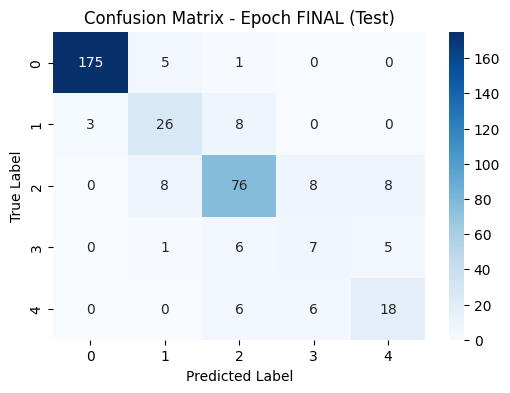

In [ ]:
# Step 3: The Training Loop with Optuna (A100 Optimized + Pruning + Fixed I/O)

import optuna
import time
import copy
import numpy as np
import shutil
import os
from tqdm import tqdm
from sklearn.metrics import cohen_kappa_score, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import pandas as pd

# Hyperparameters & Hardware Setup
BATCH_SIZE = 128
EPOCHS = 15

# A100 TENSOR CORE OPTIMIZATION
if torch.cuda.is_available() and "A100" in torch.cuda.get_device_name(0):
    print("A100 GPU detected! Enabling TF32 for maximum Tensor Core performance.")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# Augmentations for Training
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Standard Transforms for Val/Test
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Loading datasets...")
train_dataset = RetiZeroDataset('train.csv', IMAGE_DIR, transform=train_transforms)
val_dataset = RetiZeroDataset('valid.csv', IMAGE_DIR, transform=val_transforms)
test_dataset = RetiZeroDataset('test.csv', IMAGE_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Calculate Class Weights
train_df_labels = pd.read_csv('train.csv')['label'].values
class_counts = np.bincount(train_df_labels)
total_samples = len(train_df_labels)

class_weights = total_samples / (5.0 * class_counts)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

# --- 2. Evaluation Function ---
def evaluate_model(model, dataloader, criterion, epoch, phase="Validation", show_cm=False):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            # FIXED: Updated AMP syntax
            with torch.amp.autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    print(f"{phase} Loss: {epoch_loss:.4f} | Acc: {acc:.4f} | QWK: {qwk:.4f}")

    if show_cm:
        cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4])
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
        plt.title(f'Confusion Matrix - Epoch {epoch} ({phase})')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()

    return epoch_loss, acc, qwk

# 3. OPTUNA OBJECTIVE FUNCTION
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 2e-4, log=True)
    weight_decay = 1e-4

    print(f"\nStarting Trial {trial.number} | LR: {lr:.5f}")

    model = RetiZeroFinetune(weight_path=WEIGHTS_PATH, num_classes=5).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # Optional: Update scaler syntax for modern PyTorch, though the old one still works
    scaler = torch.amp.GradScaler('cuda')

    best_acc = 0.0
    best_qwk = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    patience = 4
    patience_counter = 0


    trial_weight_path = f'best_retizero_trial_{trial.number}.pth'

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()


            with torch.amp.autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        scheduler.step()

        val_loss, val_acc, val_qwk = evaluate_model(model, val_loader, criterion, epoch, phase="Validation", show_cm=False)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            print(f"Trial pruned at epoch {epoch} due to poor relative performance.")
            raise optuna.exceptions.TrialPruned()

        if val_acc > best_acc:
            print(f"Trial {trial.number} New Best Accuracy: {val_acc:.4f} (Prev: {best_acc:.4f})")
            best_acc = val_acc
            best_qwk = val_qwk
            best_model_wts = copy.deepcopy(model.state_dict())


            torch.save(best_model_wts, trial_weight_path)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    print(f"\nTrial {trial.number} Completed | Best Accuracy: {best_acc:.4f} | Corresponding QWK: {best_qwk:.4f}")
    return best_acc

# 4. RUN OPTUNA STUDY
print(" STARTING HYPERPARAMETER TUNING ")

study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3, n_startup_trials=5)
)

study.enqueue_trial({"lr": 1e-4})
study.optimize(objective, n_trials=25)

print(" TUNING COMPLETE ")
print(f"Best Overall Accuracy Achieved: {study.best_value:.4f}")


best_trial_num = study.best_trial.number
best_trial_file = f'best_retizero_trial_{best_trial_num}.pth'
master_weight_file = 'best_retizero_dr.pth'

if os.path.exists(best_trial_file):
    print(f"Loading winning weights from Trial {best_trial_num}...")
    shutil.copy(best_trial_file, master_weight_file)
else:
    print(f"Warning: Could not find {best_trial_file}.")

# 5. Final Test Set Evaluation
print("\n FINAL TEST SET EVALUATION USING OVERALL BEST WEIGHTS")
final_model = RetiZeroFinetune(weight_path=WEIGHTS_PATH, num_classes=5).to(device)
final_model.load_state_dict(torch.load(master_weight_file))
test_loss, test_acc, test_qwk = evaluate_model(final_model, test_loader, criterion, epoch="FINAL", phase="Test", show_cm=True)

#Step 4: The Inference Pipeline


🔍 RUNNING INFERENCE ON ALL 5 DR GRADES

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 Testing inference on: 04579e31e4be.png
 True Ground Truth: Normal (No DR)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

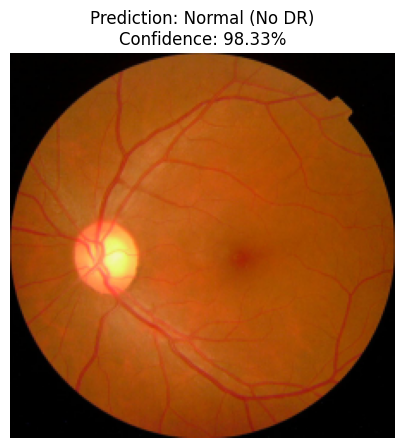


 DIAGNOSTIC BREAKDOWN
Normal (No DR)      : 98.33%
Mild NPDR           : 1.47%
Moderate NPDR       : 0.15%
Severe NPDR         : 0.03%
Proliferative DR    : 0.03%

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 Testing inference on: 0124dffecf29.png
 True Ground Truth: Mild NPDR
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

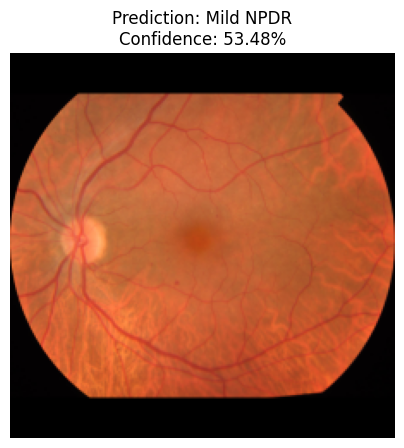


 DIAGNOSTIC BREAKDOWN
Normal (No DR)      : 36.76%
Mild NPDR           : 53.48%
Moderate NPDR       : 8.57%
Severe NPDR         : 0.42%
Proliferative DR    : 0.76%

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 Testing inference on: 032d7b0b4bf6.png
 True Ground Truth: Moderate NPDR
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

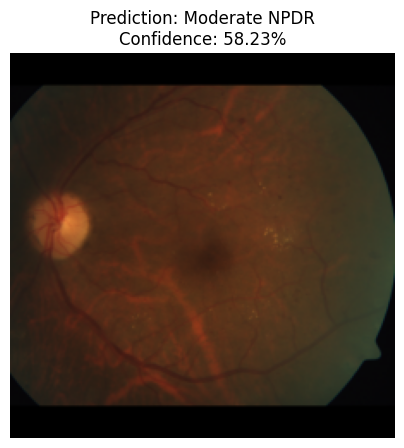


 DIAGNOSTIC BREAKDOWN
Normal (No DR)      : 1.27%
Mild NPDR           : 30.57%
Moderate NPDR       : 58.23%
Severe NPDR         : 2.01%
Proliferative DR    : 7.92%

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 Testing inference on: 0104b032c141.png
 True Ground Truth: Severe NPDR
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

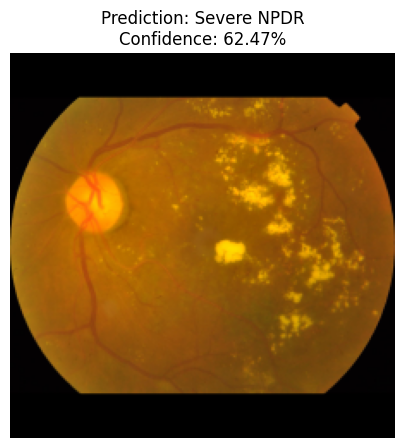


 DIAGNOSTIC BREAKDOWN
Normal (No DR)      : 0.12%
Mild NPDR           : 0.99%
Moderate NPDR       : 23.64%
Severe NPDR         : 62.47%
Proliferative DR    : 12.78%

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
 Testing inference on: 034cb07a550f.png
 True Ground Truth: Proliferative DR
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

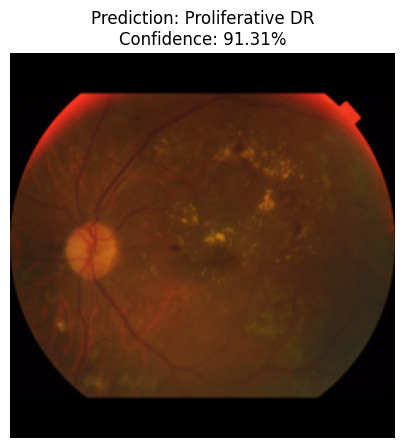


 DIAGNOSTIC BREAKDOWN
Normal (No DR)      : 0.25%
Mild NPDR           : 0.86%
Moderate NPDR       : 3.63%
Severe NPDR         : 3.96%
Proliferative DR    : 91.31%


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt

# Define the human-readable grading scale
DR_GRADES = {
    0: "Normal (No DR)",
    1: "Mild NPDR",
    2: "Moderate NPDR",
    3: "Severe NPDR",
    4: "Proliferative DR"
}

def predict_dr_grade(image_path, model_weights_path='best_retizero_dr.pth'):
    if not os.path.exists(image_path):
        print(f"Error: Could not find image at {image_path}")
        return

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Initialize Model and Load Best Weights
    model = RetiZeroFinetune(weight_path=WEIGHTS_PATH, num_classes=5).to(device)
    model.load_state_dict(torch.load(model_weights_path, map_location=device))
    model.eval()

    # 2. Prepare the Image
    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(raw_image).unsqueeze(0).to(device) # Add batch dimension

    # 3. Inference
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits = model(input_tensor)
            probabilities = F.softmax(logits, dim=1).squeeze().cpu().numpy()

    prediction_idx = probabilities.argmax()
    predicted_grade = DR_GRADES[prediction_idx]
    confidence = probabilities[prediction_idx] * 100

    # 4. Display Results
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_image)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_grade}\nConfidence: {confidence:.2f}%")
    plt.show()


    print(" DIAGNOSTIC BREAKDOWN")
    for idx, prob in enumerate(probabilities):
        print(f"{DR_GRADES[idx]:<20}: {prob*100:.2f}%")

# --- Run Inference on One Sample from EACH Class ---
test_df = pd.read_csv('test.csv')
print("\nRUNNING INFERENCE ON ALL 5 DR GRADES")

for dr_class in range(5):
    # Filter the dataframe for the current class
    class_subset = test_df[test_df['label'] == dr_class]

    if not class_subset.empty:
        sample_image_name = class_subset.iloc[0]['image_file']
        sample_image_path = os.path.join(IMAGE_DIR, sample_image_name)


        print(f" Testing inference on: {sample_image_name}")
        print(f" True Ground Truth: {DR_GRADES[dr_class]}")

        predict_dr_grade(sample_image_path)
    else:
        print(f"No samples found for Class {dr_class} in the test set.")


# Test Evaluation

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)
from tqdm import tqdm

def evaluate_comprehensive_metrics(model_architecture, dataloader, weights_path='best_retizero_dr.pth'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load the model architecture and best weights
    model = model_architecture.to(device)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    print(f"Loading weights from {weights_path} and evaluating...")

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Test Set Evaluation"):
            images, labels = images.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                logits = model(images)
                probs = F.softmax(logits, dim=1)

            preds = torch.argmax(logits, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Convert to numpy arrays for sklearn compatibility
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # Calculate individual metrics
    acc = accuracy_score(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    # Macro averages treat all classes equally, preventing majority class bias
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    # AUC-ROC using One-vs-Rest strategy
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')

    # Print the clinical report
    print("  COMPREHENSIVE TEST SET REPORT ")
    print(f"Accuracy:      {acc:.4f}  <- (Primary Optimization Metric)")
    print(f"QWK:           {qwk:.4f}")
    print(f"AUC-ROC:       {auc:.4f}  <- (Macro OVR)")
    print(f"Precision:     {precision:.4f}  <- (Macro)")
    print(f"Recall:        {recall:.4f}  <- (Macro)")
    print(f"F1 Score:      {f1:.4f}  <- (Macro)")

# Initialize a fresh architecture instance to ensure a clean evaluation slate
eval_model = RetiZeroFinetune(weight_path=WEIGHTS_PATH, num_classes=5)

# Run the comprehensive evaluation
evaluate_comprehensive_metrics(eval_model, test_loader, 'best_retizero_dr.pth')

Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights from best_retizero_dr.pth and evaluating...


Test Set Evaluation: 100%|██████████| 3/3 [00:01<00:00,  1.86it/s]


  COMPREHENSIVE TEST SET REPORT 
Accuracy:      0.8229  <- (Primary Optimization Metric)
QWK:           0.9097
AUC-ROC:       0.9451  <- (Macro OVR)
---------------------------------------------
Precision:     0.6661  <- (Macro)
Recall:        0.6796  <- (Macro)
F1 Score:      0.6724  <- (Macro)


Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Running inference for clinical plots...


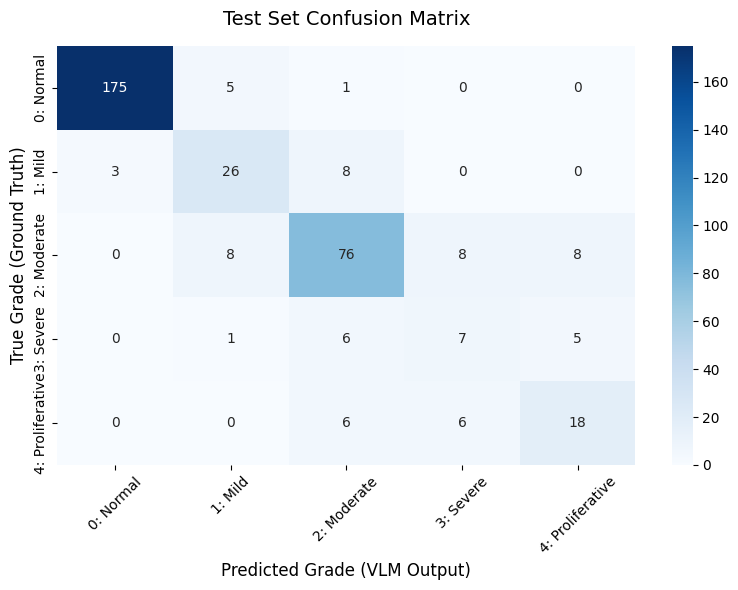


 PER-CLASS CLINICAL CLASSIFICATION REPORT
                  precision    recall  f1-score   support

       0: Normal       0.98      0.97      0.97       181
         1: Mild       0.65      0.70      0.68        37
     2: Moderate       0.78      0.76      0.77       100
       3: Severe       0.33      0.37      0.35        19
4: Proliferative       0.58      0.60      0.59        30

        accuracy                           0.82       367
       macro avg       0.67      0.68      0.67       367
    weighted avg       0.83      0.82      0.83       367




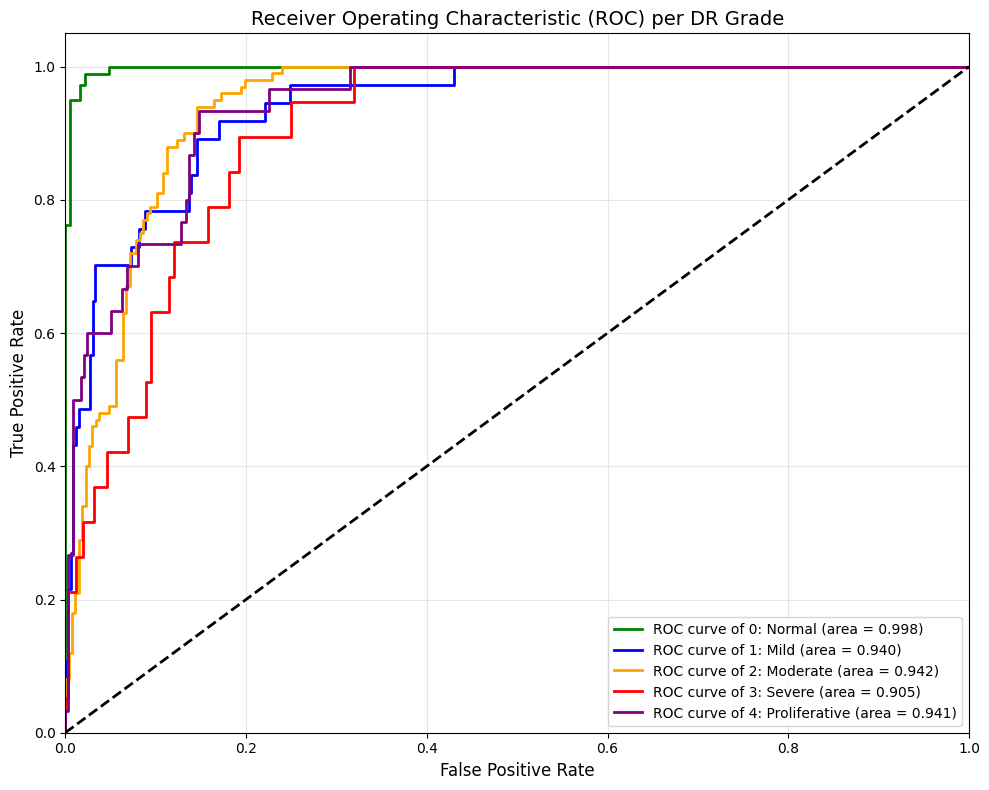

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

def generate_clinical_plots(model_architecture, dataloader, weights_path='best_retizero_dr.pth'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Load Model
    model = model_architecture.to(device)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    print("Running inference for clinical plots...")
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            # labels remain on CPU here if they aren't explicitly moved,
            # but standard practice is to ensure they are offloaded safely.


            with torch.amp.autocast('cuda'):
                logits = model(images)
                probs = F.softmax(logits, dim=1)

            preds = torch.argmax(logits, dim=1)


            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    class_names = ['0: Normal', '1: Mild', '2: Moderate', '3: Severe', '4: Proliferative']

    # PLOT 1: Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Test Set Confusion Matrix', fontsize=14, pad=15)
    plt.ylabel('True Grade (Ground Truth)', fontsize=12)
    plt.xlabel('Predicted Grade (VLM Output)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # REPORT 2: Per-Class Classification Report
    print(" PER-CLASS CLINICAL CLASSIFICATION REPORT")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # --- PLOT 3: Multiclass ROC Curves (One-vs-Rest) ---
    y_test_bin = label_binarize(all_labels, classes=[0, 1, 2, 3, 4])
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(10, 8))
    colors = ['green', 'blue', 'orange', 'red', 'purple']

    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'ROC curve of {class_names[i]} (area = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) per DR Grade', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Initialize architecture and run
eval_model = RetiZeroFinetune(weight_path=WEIGHTS_PATH, num_classes=5)
generate_clinical_plots(eval_model, test_loader, 'best_retizero_dr.pth')

# 5.5: Exporting for Streamlit Deployment

In [ ]:
import torch
import shutil

# 1. Define paths
drive_export_path_full = '/content/drive/MyDrive/DR_Project/retizero_full_model.pth'
drive_export_path_weights = '/content/drive/MyDrive/DR_Project/retizero_best_weights.pth'

# 2. Ensure we have the absolute best architecture loaded
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_model = RetiZeroFinetune(weight_path=WEIGHTS_PATH, num_classes=5).to(device)
final_model.load_state_dict(torch.load('best_retizero_dr.pth', map_location=device))

# 3. Save the ENTIRE model object (Architecture + Weights)
print("Saving the complete model object...")
torch.save(final_model, 'retizero_full_model.pth')
shutil.copy('retizero_full_model.pth', drive_export_path_full)
print(f"Full model saved to Drive: {drive_export_path_full}")

# 4. Save the exact State Dict (Safest for Streamlit)
print("Saving the isolated weights...")
shutil.copy('best_retizero_dr.pth', drive_export_path_weights)
print(f"Safe weights saved to Drive: {drive_export_path_weights}")

Loading RetiZero weights manually to bypass buffer mismatch...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Saving the complete model object...
Full model saved to Drive: /content/drive/MyDrive/DR_Project/retizero_full_model.pth
Saving the isolated weights...
Safe weights saved to Drive: /content/drive/MyDrive/DR_Project/retizero_best_weights.pth


In [ ]:
from google.colab import files

# Download the safe weights (Priority for your Streamlit app)
print("Initiating download for the Streamlit-safe weights...")
files.download('best_retizero_dr.pth')


Initiating download for the Streamlit-safe weights...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Initiating download for the full model object...")
files.download('retizero_full_model.pth')

Initiating download for the full model object...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>